# Clients and Task Types

Client mix, client constraints, sector/task patterns, and review workflow behavior.

In [2]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

ROOT = Path.cwd().resolve()
while not (ROOT / "agents.md").exists():
    if ROOT.parent == ROOT:
        raise RuntimeError("Could not locate project root from notebook directory.")
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

warnings.filterwarnings("ignore")
pd.options.display.max_columns = 120
pd.options.display.max_rows = 50

from data_analysis._shared.eda_utils import (
    ENRICHED_PATH,
    FEATURE_GROUPS,
    NUMERIC_OUTLIER_COLUMNS,
    build_enriched_tasks,
    categorical_variants,
    cross_sheet_consistency_report,
    detect_outliers,
    diagnose_client_unmatched,
    diagnose_pair_unmatched,
    diagnose_schedule_unmatched,
    dtype_audit,
    exact_duplicates,
    join_datasets,
    load_all_data,
    load_enriched_tasks,
    missing_summary,
    missingness_by_group,
    missingness_correlation,
    near_duplicates_data,
    proofread_reviewer_comparison,
    same_language_examples,
    same_language_report,
    set_plot_style,
    sheet_dimensions_report,
    summarize_join_integrity,
    timestamp_logic_report,
    timestamp_violation_samples,
    translator_on_time_summary,
    translator_quality_summary,
    wilson_interval,
    zero_value_report,
)

set_plot_style()
sheets = load_all_data()
data = sheets["data"]
schedules = sheets["schedules"]
clients = sheets["clients"]
pairs = sheets["pairs"]
print(f"Loaded Data={data.shape}, Schedules={schedules.shape}, Clients={clients.shape}, Pairs={pairs.shape}")

Loaded Data=(997933, 29), Schedules=(983, 11), Clients=(2645, 6), Pairs=(4688, 7)


In [3]:
overlap = len(set(data["MANUFACTURER"]) & set(clients["CLIENT_NAME"]))
display(
    pd.DataFrame(
        [
            {"metric": "Unique clients in Data", "value": data["MANUFACTURER"].nunique()},
            {"metric": "Unique clients in Clients sheet", "value": clients["CLIENT_NAME"].nunique()},
            {"metric": "Exact overlap", "value": overlap},
        ]
    )
)

,metric,value
0,Unique clients in Data,2645
1,Unique clients in Clients sheet,2645
2,Exact overlap,2645


In [4]:
client_volume = (
    data.groupby("MANUFACTURER")
    .agg(task_count=("TASK_ID", "size"), total_hours=("HOURS", "sum"))
    .sort_values("task_count", ascending=False)
    .reset_index()
)
display(client_volume.head(20))
display(client_volume.sort_values("total_hours", ascending=False).head(20))

,MANUFACTURER,task_count,total_hours
0,TrueConnect,258435,176552.43
1,AeroSysTech,167992,267979.82
2,FrontierTech,66657,93687.84
3,NextGen Industries,46321,64199.08
4,HealthyLife,20250,63462.91
5,InduNet Solutions,19881,12678.64
6,NexisOne,13134,19169.50
7,MindSpark Media,12240,17682.12
8,MotorForge,11451,73440.45
9,QuantumLogic,10184,21777.30


,MANUFACTURER,task_count,total_hours
1,AeroSysTech,167992,267979.82
0,TrueConnect,258435,176552.43
2,FrontierTech,66657,93687.84
8,MotorForge,11451,73440.45
3,NextGen Industries,46321,64199.08
4,HealthyLife,20250,63462.91
9,QuantumLogic,10184,21777.30
29,Flux Fuel,4244,21188.14
6,NexisOne,13134,19169.50
19,NanoWorks Research Corp,4998,18497.82


,value
count,2645.000000
mean,5.019282
std,3.545256
min,0.000000
25%,0.000000
50%,7.000000
75%,7.500000
max,8.000000


,metric,value
0,Clients with MIN_QUALITY = 0 (%),33.08


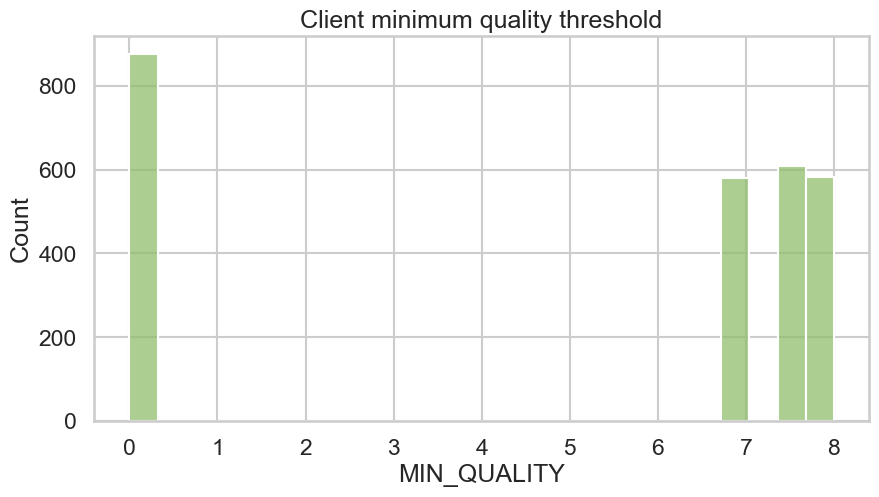

In [5]:
display(clients["MIN_QUALITY"].describe().to_frame("value"))
zero_threshold_share = (clients["MIN_QUALITY"].fillna(0) == 0).mean() * 100
display(pd.DataFrame([{"metric": "Clients with MIN_QUALITY = 0 (%)", "value": round(zero_threshold_share, 2)}]))

plt.figure(figsize=(10, 5))
sns.histplot(clients["MIN_QUALITY"].dropna(), bins=25, color="#90be6d")
plt.title("Client minimum quality threshold")
plt.show()

,value
count,2645.000000
mean,34.871456
std,10.112011
min,20.000000
25%,25.000000
50%,35.000000
75%,45.000000
max,50.000000


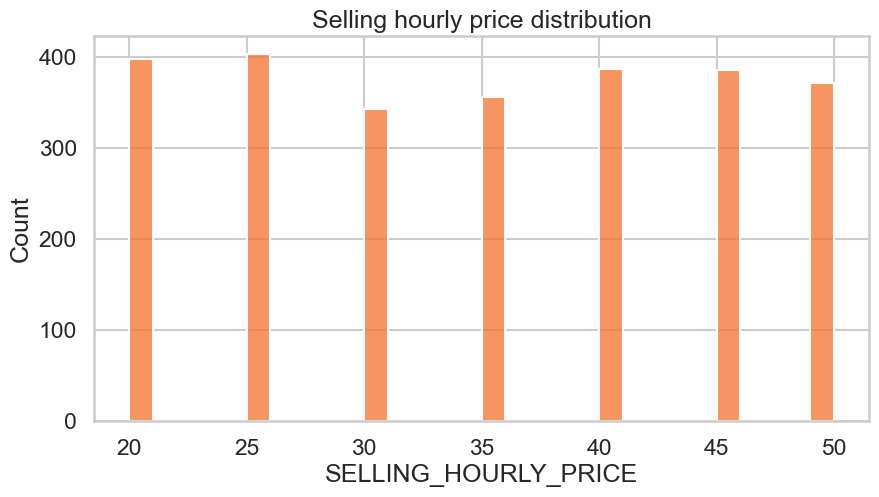

,wildcard,clients
0,Deadline,916
1,Quality,875
2,Price,854


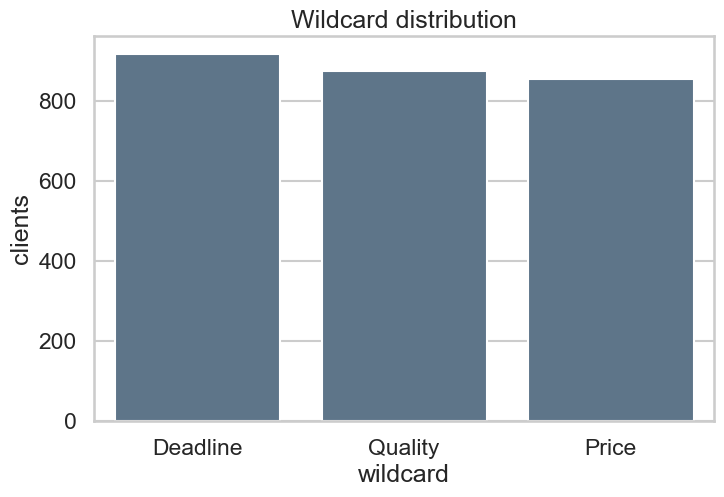

In [6]:
display(clients["SELLING_HOURLY_PRICE"].describe().to_frame("value"))
plt.figure(figsize=(10, 5))
sns.histplot(clients["SELLING_HOURLY_PRICE"].dropna(), bins=30, color="#f3722c")
plt.title("Selling hourly price distribution")
plt.show()

wildcard_dist = clients["WILDCARD_CLEAN"].value_counts(dropna=False).rename_axis("wildcard").reset_index(name="clients")
display(wildcard_dist)
plt.figure(figsize=(8, 5))
sns.barplot(data=wildcard_dist, x="wildcard", y="clients", color="#577590")
plt.title("Wildcard distribution")
plt.show()

TASK_TYPE_CLEAN,DTP,Engineering,LanguageLead,Management,Miscellaneous,PostEditing,ProofReading,ProofReadingOnly,Spotcheck,TEST,Training,Translation,TranslationOnly
MANUFACTURER,,,,,,,,,,,,,
AeroSysTech,0.000048,0.018810,0.005185,0.000107,0.131804,0.137834,0.363839,0.000042,0.000000,0.000054,0.000000,0.342248,0.000030
Bold Ventures,0.000000,0.000000,0.003244,0.001442,0.275381,0.000000,0.362610,0.000000,0.000000,0.000000,0.000000,0.357323,0.000000
FrontierTech,0.000000,0.002550,0.002565,0.005911,0.034565,0.007306,0.488171,0.000000,0.000015,0.000120,0.000000,0.458797,0.000000
HealthyLife,0.002617,0.012395,0.002025,0.004642,0.135654,0.007753,0.430914,0.000148,0.000049,0.002519,0.000000,0.401235,0.000049
InduNet Solutions,0.000000,0.000000,0.000604,0.000000,0.077712,0.047130,0.460238,0.000000,0.000000,0.000000,0.000000,0.414315,0.000000
MindSpark Media,0.000000,0.003268,0.005065,0.000000,0.037745,0.002451,0.258007,0.000000,0.000000,0.000327,0.000000,0.693137,0.000000
MotorForge,0.000000,0.005414,0.006026,0.006462,0.091957,0.165662,0.328094,0.000000,0.000087,0.000000,0.000000,0.395773,0.000524
NexisOne,0.000000,0.000990,0.000000,0.000609,0.027714,0.000761,0.490787,0.000000,0.000000,0.000152,0.000000,0.478986,0.000000
NextGen Industries,0.000000,0.000086,0.012802,0.000065,0.050539,0.621295,0.273051,0.000453,0.000065,0.000043,0.000108,0.041493,0.000000


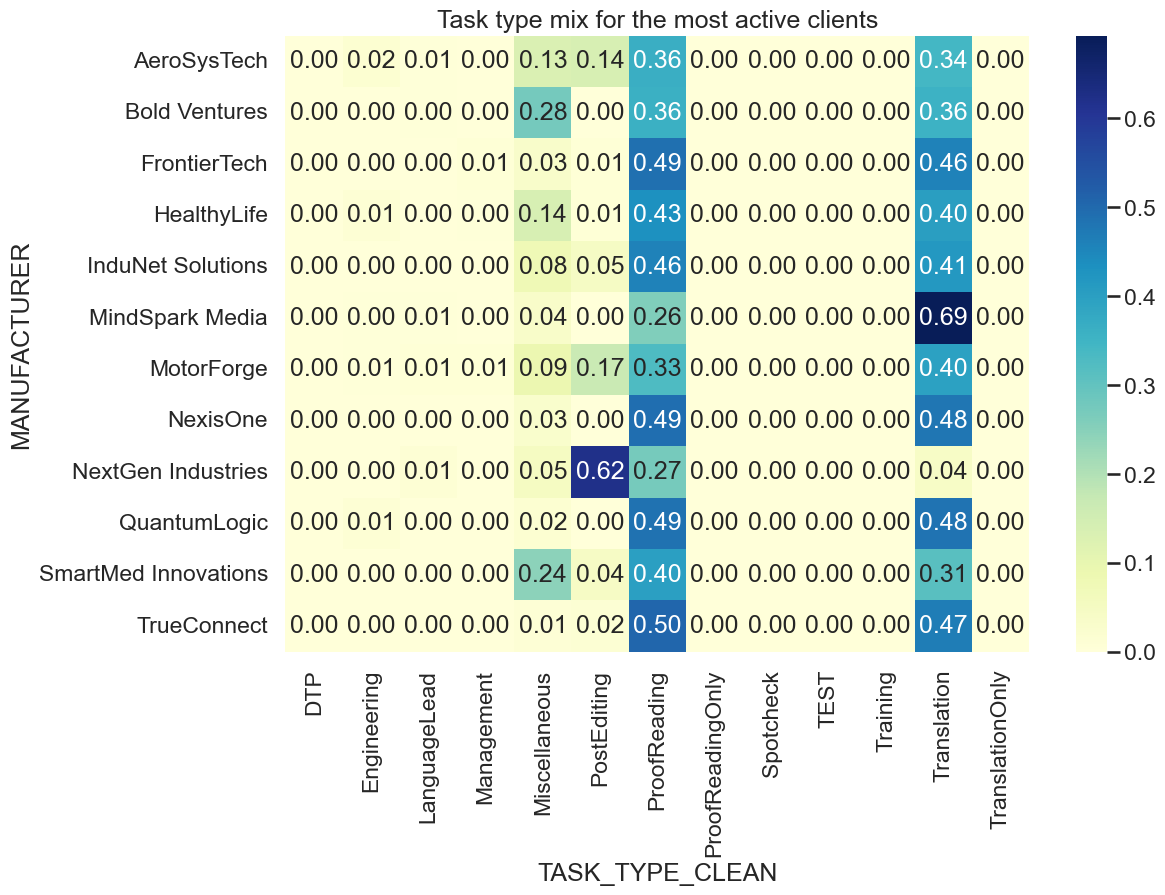

In [7]:
top_clients = data["MANUFACTURER"].value_counts().head(12).index
client_task_mix = pd.crosstab(
    data.loc[data["MANUFACTURER"].isin(top_clients), "MANUFACTURER"],
    data.loc[data["MANUFACTURER"].isin(top_clients), "TASK_TYPE_CLEAN"],
    normalize="index",
)
display(client_task_mix)

plt.figure(figsize=(12, 8))
sns.heatmap(client_task_mix, cmap="YlGnBu", annot=True, fmt=".2f")
plt.title("Task type mix for the most active clients")
plt.show()

,sector,task_count
0,Information Technology,379310
1,Communication Services,310322
2,Consumer Discretionary & Services,111221
3,Health Care,104450
4,"Industrials, Transportation & Commercial Services",59833
5,Real Estate,15440
6,Financials,5484
7,Consumer Staples & Non-Cyclical Goods,4242
8,Materials & Mining,3535
9,"Public, Education & Non-Profit",1722


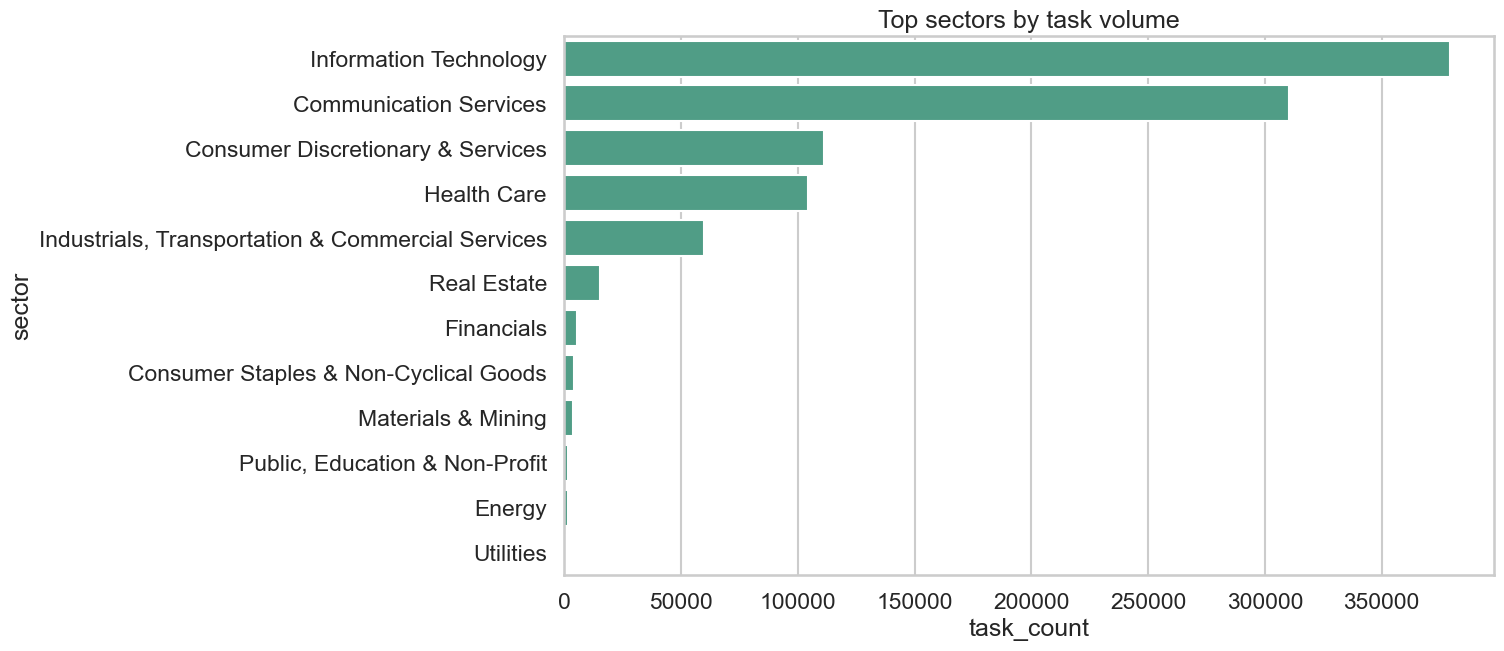

In [8]:
sector_breakdown = (
    data["MANUFACTURER_SECTOR"]
    .value_counts()
    .rename_axis("sector")
    .reset_index(name="task_count")
)
display(sector_breakdown)

plt.figure(figsize=(12, 7))
sns.barplot(data=sector_breakdown.head(15), x="task_count", y="sector", color="#43aa8b")
plt.title("Top sectors by task volume")
plt.show()

In [9]:
client_quality = (
    data.groupby("MANUFACTURER")
    .agg(avg_quality=("QUALITY_EVALUATION", "mean"), scored_tasks=("QUALITY_EVALUATION", "count"))
    .query("scored_tasks >= 20")
    .sort_values("avg_quality", ascending=False)
    .reset_index()
)
display(client_quality.head(20))
display(client_quality.tail(20))

,MANUFACTURER,avg_quality,scored_tasks
0,MindMeld Media,8.259259,27
1,SoftVantage,8.096154,52
2,VoiceCom,8.087054,1792
3,The Solution Factory,8.070617,2025
4,Nova Industrial,7.973684,38
5,ChainCraft,7.901961,51
6,CloudNation,7.880874,915
7,SoftEcology,7.866036,3486
8,TechFlow,7.800000,20
9,BlueStream,7.800000,40


,MANUFACTURER,avg_quality,scored_tasks
855,WorkforceForge,6.500000,52
856,OptiFlex Industries,6.500000,36
857,MaxPower Industries,6.500000,26
858,MedHero,6.482759,29
859,Greener Homes,6.481481,54
860,Horizon Manufacturing,6.458333,24
861,FusionWorks Industrial Solutions,6.454545,22
862,EonTech,6.448276,29
863,MachineMind,6.444444,27
864,MobileMaven,6.428571,28


In [10]:
proofread_compare = proofread_reviewer_comparison(data)
display(proofread_compare)

workflow = data.sort_values(["PROJECT_ID", "START", "TASK_ID"]).copy()
workflow["NEXT_TASK_TYPE"] = workflow.groupby("PROJECT_ID")["TASK_TYPE_CLEAN"].shift(-1)
workflow["NEXT_TRANSLATOR"] = workflow.groupby("PROJECT_ID")["TRANSLATOR"].shift(-1)
spotcheck = workflow[
    workflow["TASK_TYPE_CLEAN"].isin(["Translation", "TranslationOnly"])
    & workflow["NEXT_TASK_TYPE"].eq("Spotcheck")
].copy()
spotcheck["same_translator"] = spotcheck["TRANSLATOR"] == spotcheck["NEXT_TRANSLATOR"]
display(
    spotcheck["same_translator"]
    .value_counts(dropna=False)
    .rename_axis("same_translator")
    .reset_index(name="count")
)

,same_translator,count
0,False,214985
1,True,4692


,same_translator,count
0,False,9


In [11]:
test_tasks = data.loc[data["TASK_TYPE_CLEAN"].eq("TEST")].copy()
display(
    pd.DataFrame(
        [
            {"metric": "TEST tasks", "value": len(test_tasks)},
            {"metric": "Unique translators on TEST tasks", "value": test_tasks["TRANSLATOR"].nunique()},
        ]
    )
)
display(test_tasks["TRANSLATOR"].value_counts().head(20).rename_axis("translator").reset_index(name="test_tasks"))

,metric,value
0,TEST tasks,192
1,Unique translators on TEST tasks,93


,translator,test_tasks
0,Fortunato,12
1,Maximo,11
2,Vinicius,8
3,Christian,8
4,Luis Felipe,7
5,Ana Daniela,6
6,Reinaldo,5
7,Pol,5
8,Roque Marlene,5
9,Clarice,4
